In [6]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import os
import copy

from functools import partial, reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pingouin as pg
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import matplotlib.colors as mcolors

In [8]:
import utils as ut

In [9]:
pd.set_option('display.max_columns', 100)

In [17]:
# test run of the model for dev purposes, or full/final data set?
is_testcase = False

# Load Model Results from Disk

In [18]:
l_data_subset = ["full"]
l_rnd_seed = [1]
l_embed_dim = [35]
modeltype = "free_weights_no_scaling"
modelversion = "embeddings-decision-combined-data"
l_id_weights = ["separate"]
l_lmbda = [1e-07]

# was the flag shared or separate set?
is_shared_separate = True

# load results from model run
l_results_full = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)[0]

In [19]:
l_rnd_seed = [1]
l_data_subset = ["first_half", "second_half"]

# load results from model run
l_results_splithalf = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)[0]

In [70]:
use_procrustes = True

range_dims = range(l_embed_dim[0], l_embed_dim[0]+1)

partial_sims = partial(ut.dimensional_similarities, l_results_splithalf, use_procrustes=use_procrustes)
l_cors = list(map(partial_sims, range_dims))


dict_cors = {int(f'{range_dims[i]}'): sublist for i, sublist in enumerate(l_cors)}

partial_reorder = partial(ut.reorder_dimensions, l_results_splithalf, use_procrustes=use_procrustes)
l_max_sims = list(map(partial_reorder, range_dims))
dict_max_sims = dict(zip(range_dims, l_max_sims))

if use_procrustes:
    dict_idxs_use = ut.max_average_similarity_and_reliability(dict_cors, l_results_splithalf)
else:
    dict_idxs_use = ut.max_sim_dimensions_per_ndim(l_max_sims, range_dims)
dict_idxs_list_use = ut.max_sim_results_per_ndim(dict_idxs_use, dict_max_sims, range_dims)

if not use_procrustes:
    # no unique mapping for 15 dims, just use the first for visualizing
    dict_idxs_use[35] = 0
    dict_idxs_list_use[35] = [0, 1]

In [71]:
# Load Relevant IDs for correlational analyses
if is_testcase:
    df_pids = pd.read_csv("data/study1-2025-08/new-participant-ids-in-joint-modeling-testcase.csv")
elif not is_testcase:
    df_pids = pd.read_csv("data/study1-2025-08/new-participant-ids-in-joint-modeling.csv")

In [72]:
l_pids_model = list(df_pids["participant_id_model"])
l_pids_new = list(df_pids["participant_id_new"])

In [73]:
idx_full = 0
idx_h1 = dict_idxs_list_use[l_embed_dim[0]][0]
idx_h2 = dict_idxs_list_use[l_embed_dim[0]][1]

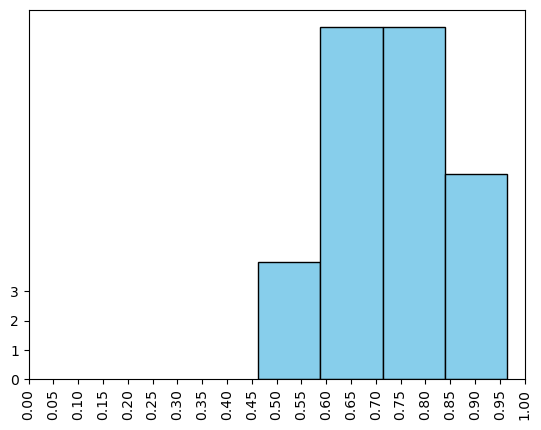

In [74]:
plt.hist(l_cors[0][0][dict_idxs_use[l_embed_dim[0]]].max(axis=1), bins=4, color="skyblue", edgecolor="black")
plt.yticks(range(0, 4))
plt.xticks(np.linspace(0, 1, 21), rotation=90)
_ = plt.xlim((0, 1))

do this twice:
- first, only for the new batch of participants (i.e., 2025/08)
- then, for all available participants in the model (i.e., including THINGS participants), because we have age and gender for most of those as well

In [75]:
l_results_full[0]["decision_weights"].shape

torch.Size([978, 35])

In [76]:
# new participants
df_dim_weights = ut.extract_dim_weight_results(l_results_full, idx_full, l_embed_dim[0], l_pids_model, l_pids_new)
df_dim_weights_h1 = ut.extract_dim_weight_results(l_results_splithalf, idx_h1, l_embed_dim[0], l_pids_model, l_pids_new)
df_dim_weights_h2 = ut.extract_dim_weight_results(l_results_splithalf, idx_h2, l_embed_dim[0], l_pids_model, l_pids_new)
df_dim_weights, colnames_dim_weights = ut.rename_dim_weight_cols(df_dim_weights, l_embed_dim[0])
df_dim_weights_h1, _ = ut.rename_dim_weight_cols(df_dim_weights_h1, l_embed_dim[0])
df_dim_weights_h2, _ = ut.rename_dim_weight_cols(df_dim_weights_h2, l_embed_dim[0])

In [77]:
# THINGS participants
df_things_participants = pd.read_csv("data/THINGS-demographic-lookup.csv")
df_things_participants.rename(
    columns={"subject_id":"participant_id_model", "subject_id_THINGS": "participant_id_THINGS"},
    inplace=True
)
df_things_participants["participant_id_new"] = np.nan
df_things_participants['gender_num'] = df_things_participants['gender'].apply(
    lambda x: 0 if x == "male" else 1 if x == "female" else 2
)
df_things_participants.drop(columns=["gender", "participant_id_THINGS", "n"], inplace=True)
# same naming as in new data
df_things_participants.rename(
    columns={"gender_num":"Sex_0", "mn_age":"age", "mn_RT": "rt", "participant_id_new": "pid"},
    inplace=True)
df_things_participants.head()

l_pids_model_THINGS = df_things_participants["participant_id_model"].tolist()
l_pids_model_THINGS_new = df_things_participants["pid"].tolist()

df_dim_weights_THINGS = ut.extract_dim_weight_results(l_results_full, idx_full, l_embed_dim[0], l_pids_model_THINGS, l_pids_model_THINGS_new)
df_dim_weights_h1_THINGS = ut.extract_dim_weight_results(l_results_splithalf, idx_h1, l_embed_dim[0], l_pids_model_THINGS, l_pids_model_THINGS_new)
df_dim_weights_h2_THINGS = ut.extract_dim_weight_results(l_results_splithalf, idx_h2, l_embed_dim[0], l_pids_model_THINGS, l_pids_model_THINGS_new)
df_dim_weights_THINGS, colnames_dim_weights = ut.rename_dim_weight_cols(df_dim_weights_THINGS, l_embed_dim[0])
df_dim_weights_h1_THINGS, _ = ut.rename_dim_weight_cols(df_dim_weights_h1_THINGS, l_embed_dim[0])
df_dim_weights_h2_THINGS, _ = ut.rename_dim_weight_cols(df_dim_weights_h2_THINGS, l_embed_dim[0])

In [78]:
# load dfs saved with R (after applying exclusion criteria)
df_qs_num_long = pd.read_csv("data/study1-2025-08/tbl_qs_num_long_excluded.csv")
df_qs_txt = pd.read_csv("data/study1-2025-08/tbl_qs_txt_excluded.csv")
df_qs_num = df_qs_num_long.pivot(index=["participant_id", "session_id"], columns="name", values="value").reset_index(drop=False)

In [79]:
# read average RT per participant
df_avg = pd.read_csv("data/study1-2025-08/avg-rt.csv")

In [80]:
# use average triplet rt, not time taken for questionnaires
df_qs_num = pd.merge(df_qs_num.drop(columns=["rt"]), df_avg.drop(columns=["participant_id_model"]), how="left", on="participant_id")
df_qs_num.rename(columns={"mn_rt":"rt"}, inplace=True)

In [81]:
df_qs_num.columns

Index(['participant_id', 'session_id', 'BIG5_SF_0', 'BIG5_SF_1', 'BIG5_SF_10',
       'BIG5_SF_11', 'BIG5_SF_12', 'BIG5_SF_13', 'BIG5_SF_14', 'BIG5_SF_15',
       'BIG5_SF_16', 'BIG5_SF_17', 'BIG5_SF_18', 'BIG5_SF_19', 'BIG5_SF_2',
       'BIG5_SF_20', 'BIG5_SF_21', 'BIG5_SF_22', 'BIG5_SF_23', 'BIG5_SF_24',
       'BIG5_SF_25', 'BIG5_SF_26', 'BIG5_SF_27', 'BIG5_SF_28', 'BIG5_SF_29',
       'BIG5_SF_3', 'BIG5_SF_4', 'BIG5_SF_5', 'BIG5_SF_6', 'BIG5_SF_7',
       'BIG5_SF_8', 'BIG5_SF_9', 'I_8_0', 'I_8_1', 'I_8_2', 'I_8_3', 'I_8_4',
       'I_8_5', 'I_8_6', 'I_8_7', 'PID5_BF_0', 'PID5_BF_1', 'PID5_BF_10',
       'PID5_BF_11', 'PID5_BF_12', 'PID5_BF_13', 'PID5_BF_14', 'PID5_BF_15',
       'PID5_BF_16', 'PID5_BF_17', 'PID5_BF_18', 'PID5_BF_19', 'PID5_BF_2',
       'PID5_BF_20', 'PID5_BF_21', 'PID5_BF_22', 'PID5_BF_23', 'PID5_BF_24',
       'PID5_BF_3', 'PID5_BF_4', 'PID5_BF_5', 'PID5_BF_6', 'PID5_BF_7',
       'PID5_BF_8', 'PID5_BF_9', 'Sex_0', 'age', 'attention_2', 'diagnosis_2',
       'e

In [82]:
# reverse code items
df_qs_num = ut.reverse_code_q_items(df_qs_num)
# create scale and facet scores
df_qs_num = ut.scales_and_facets(df_qs_num)
# only keep scales, drop items and facets
df_qs_num = ut.keep_scales_only(df_qs_num)
df_qs_num.drop(columns=["diagnosis_2", "meds_3", "attention_2", "rwn"], inplace=True)

In [83]:
df_qs_num_hm = df_qs_num.copy()
df_qs_num_hm.columns = ['PID', 'Session ID', 'Gender (1 = Women)', 'Age', 'Years Education', 'idx',
       'Income', 'Motivation (Self Report)', 'Avg. RT Triplet', 'Extraversion', 'Agreeableness',
       'Conscientiousness', 'Negative Emotionality', 'Open Mindedness',
       'Negative Affect', 'Detachment', 'Antagonism', 'Disinhibition',
       'Psychoticism', 'Impulsivity']
df_qs_num_hm.drop(columns=["idx", "PID", "Session ID"], inplace=True)

In [84]:
df_qs_num_hm.columns

Index(['Gender (1 = Women)', 'Age', 'Years Education', 'Income',
       'Motivation (Self Report)', 'Avg. RT Triplet', 'Extraversion',
       'Agreeableness', 'Conscientiousness', 'Negative Emotionality',
       'Open Mindedness', 'Negative Affect', 'Detachment', 'Antagonism',
       'Disinhibition', 'Psychoticism', 'Impulsivity'],
      dtype='object')

In [85]:
df_qs_num_hm.to_csv("data/dataframes-plotting-ms/qs-dems-correlations.csv")

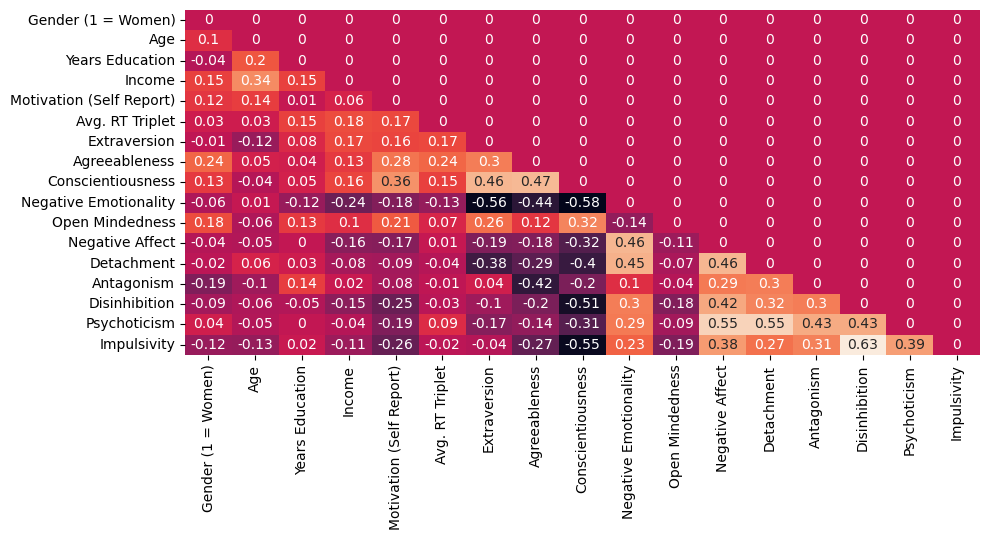

In [86]:
f, ax = plt.subplots(1, figsize=(10, 5.5))

df_hm = pd.DataFrame(np.tril(np.round(np.corrcoef(df_qs_num_hm.transpose()), 2), k=-1))
df_hm.columns = df_qs_num_hm.columns
df_hm.index = df_qs_num_hm.columns
sns.heatmap(df_hm, annot=True, ax=ax, cbar=False)

_ = plt.tight_layout()

In [87]:
df_ooo_qs = df_dim_weights.merge(df_qs_num, how="left", left_on="participant_id_new", right_on="participant_id")
# rename participant id col
df_ooo_qs.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_h1.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_h2.rename(columns={"participant_id_new":"pid"}, inplace=True)

In [88]:
def weights_delta_gini(df_h1, df_h2, df_to_merge_in, pid_str):
    
    # absolute sum of deltas of dimensional weights between halves
    df_both_halves = pd.merge(df_h1, df_h2, how="left", on=pid_str, suffixes=["_h1", "_h2"])
    for cn in colnames_dim_weights:
        df_both_halves[f"""{cn}_delta"""] = df_both_halves[f"""{cn}_h2"""] - df_both_halves[f"""{cn}_h1"""]
    df_both_halves["delta_abs_sum"] = np.sum(np.abs(df_both_halves[[c + "_delta" for c in colnames_dim_weights]]), axis=1)
    # assign to omnibus df
    df_to_merge_in["weights_delta_abs_sum"] = df_both_halves["delta_abs_sum"]
    
    # gini coef on distribution of weights
    df_gini = df_to_merge_in[[pid_str] + colnames_dim_weights].melt(id_vars=pid_str, value_name="weight", var_name="dimension")
    ginis = df_gini.groupby(pid_str)[["weight"]].agg(ut.gini).reset_index()
    ginis.columns = [pid_str, "gini_overall"]
    
    # gini coef on distribution of change of weights (i.e., same features weighted similarly across split halfs?)
    df_gini_all, icc_ginis = ut.gini_of_halves(df_both_halves, ginis, colnames_dim_weights, pid_str)
    
    # and merge ginis again with omnibus df
    df_to_merge_in = pd.merge(df_to_merge_in, df_gini_all, how="left", on=pid_str)

    return df_to_merge_in

In [89]:
df_ooo_qs = weights_delta_gini(df_dim_weights_h1, df_dim_weights_h2, df_ooo_qs, "pid")
df_dim_weights_h1_THINGS.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_h2_THINGS.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_THINGS.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_THINGS = weights_delta_gini(df_dim_weights_h1_THINGS, df_dim_weights_h2_THINGS, df_dim_weights_THINGS, "participant_id_model")

In [90]:
df_dim_weights_THINGS = pd.merge(df_dim_weights_THINGS, df_things_participants, how="left", on=["participant_id_model", "pid"])

In [91]:
df_ooo_qs.query("Sex_0 in (0, 1)", inplace=True)

In [92]:
df_ooo_qs["age_bin"] = pd.cut(df_ooo_qs["age"], bins=[0, 21, 30, 59, 70], labels=False)

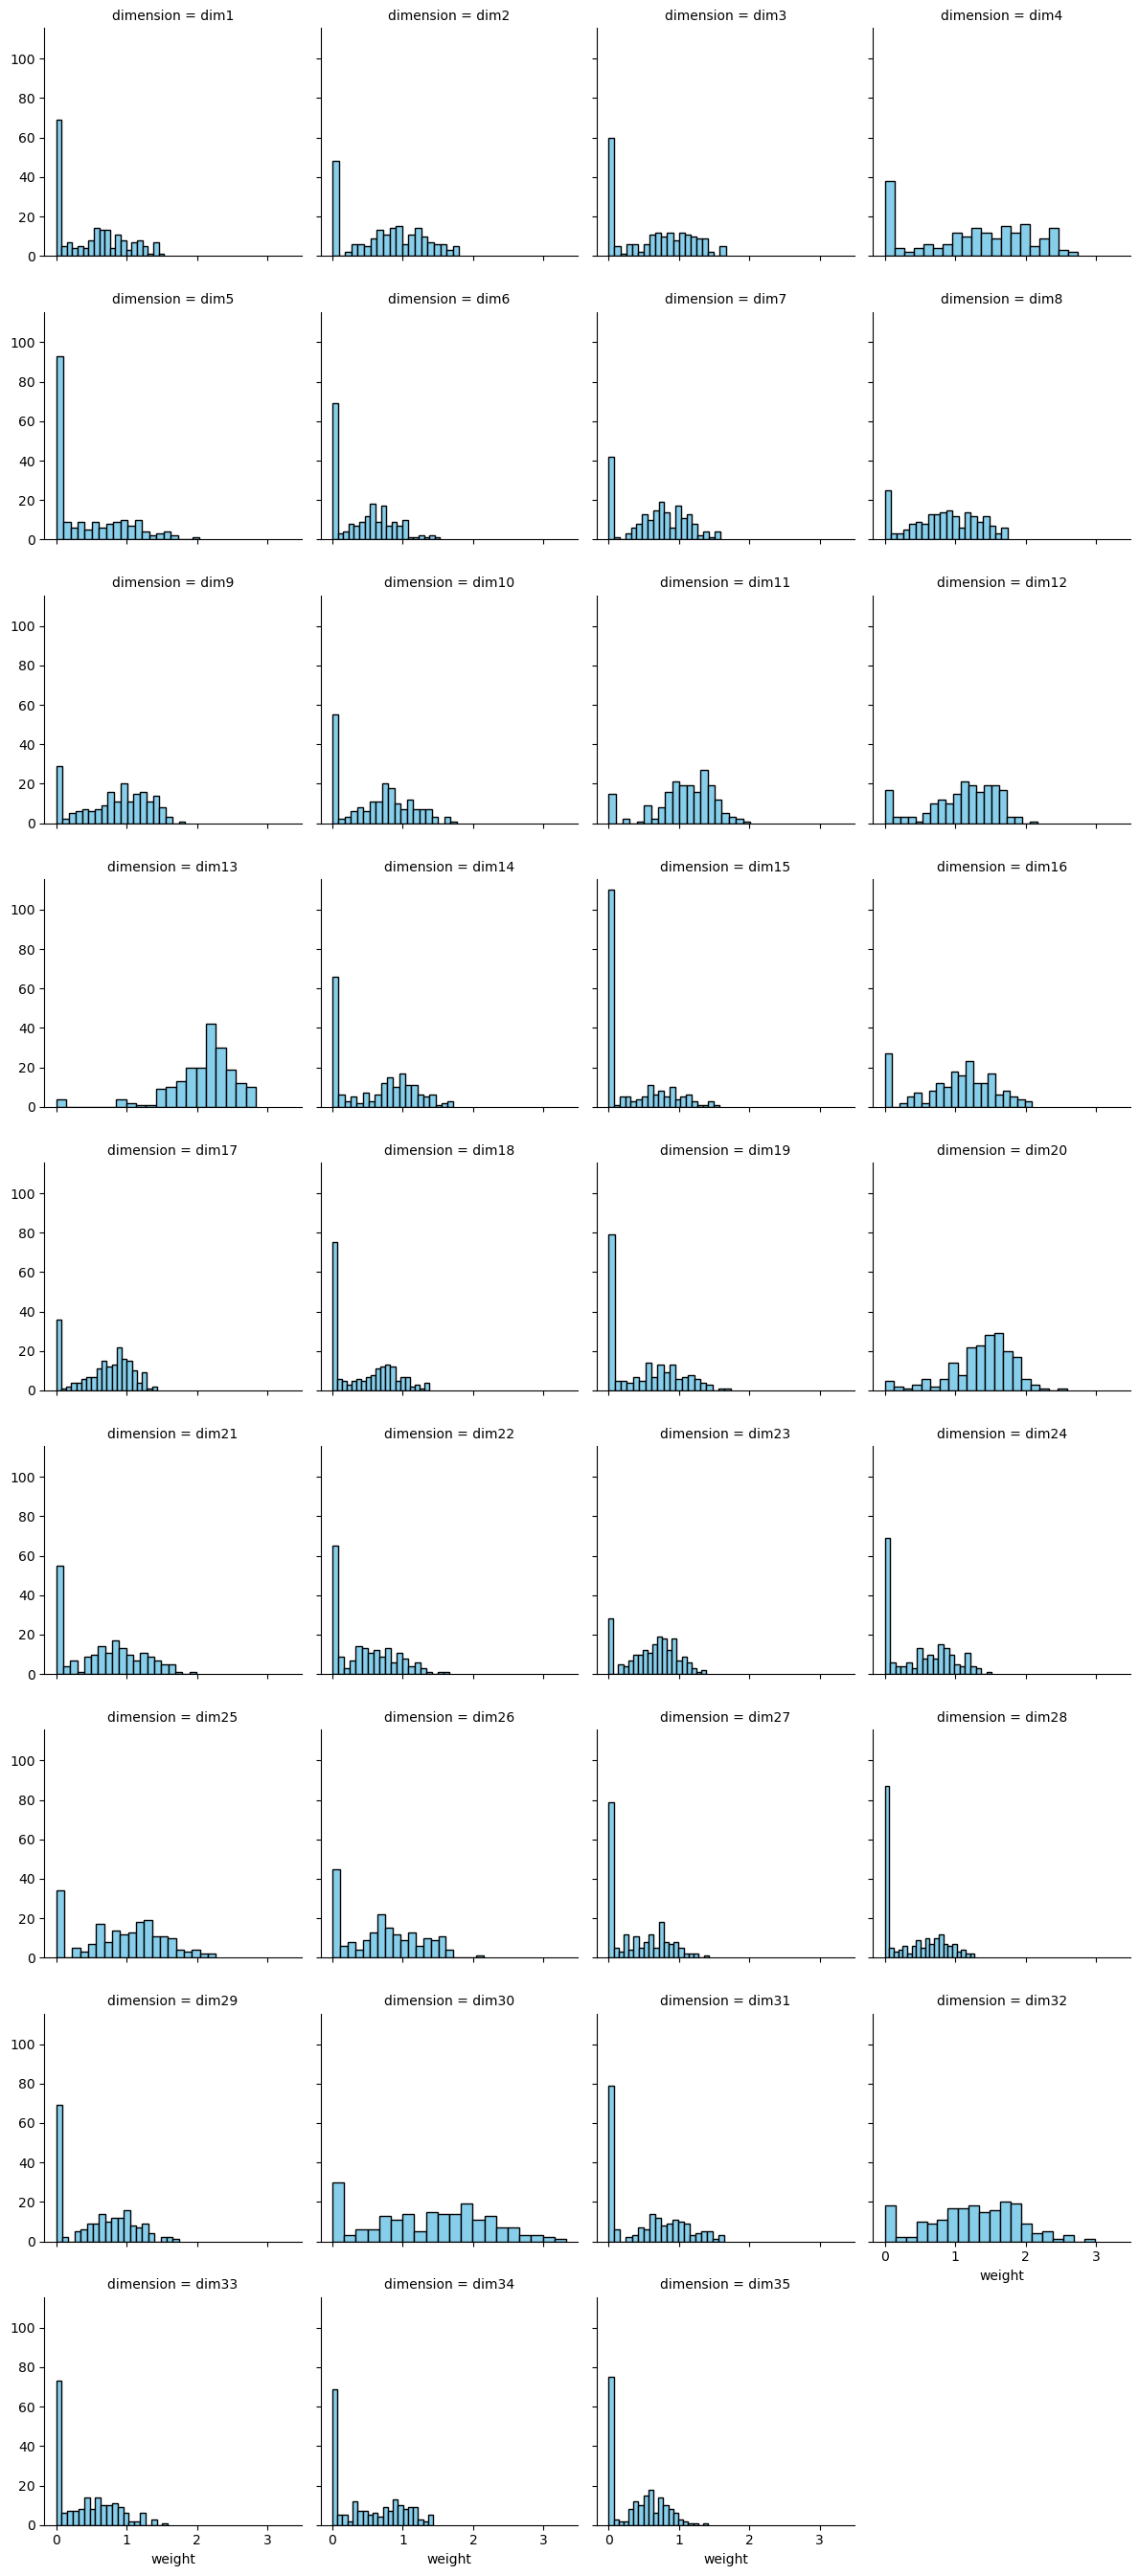

In [93]:
df_dims_long = df_ooo_qs[["pid"] + colnames_dim_weights].melt(id_vars="pid", var_name="dimension", value_name="weight")
g = sns.FacetGrid(data=df_dims_long, col="dimension", col_wrap=4)
_ = g.map(plt.hist, "weight", bins=20, color="skyblue", edgecolor="black")

In [94]:
cols_corr_new = ['edu', 'income_0', 'motivation_1', "idx",
       'Extraversion', 'Agreeableness', 'Conscientiousness',
       'Negative_Emotionality', 'Open_Mindedness', 'Negative Affect',
       'Detachment', 'Antagonism', 'Disinhibition', 'Psychoticism',
       'Impulsivity']
cols_corr_combined = ["age", "Sex_0", "rt"]

In [95]:
from scipy.stats import pearsonr

In [96]:
def corr_weight(col_str, col_str_fixed, df_cor):
    x=df_cor[col_str]
    y=df_cor[col_str_fixed]
    mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]
    corcoef, pval = pearsonr(x_clean, y_clean)
    return corcoef, pval

In [97]:
f_partial = partial(corr_weight, col_str_fixed = "avg_weight", df_cor = df_ooo_qs)
l_cors_weight = list(map(f_partial, cols_corr_new))
df_corr_weight = pd.DataFrame({"var":cols_corr_new, "r":[float(c[0]) for c in l_cors_weight], "pval":[float(c[1]) for c in l_cors_weight]})
df_corr_weight_new = df_corr_weight.sort_values("r", ascending=False).reset_index(drop=True)

f_partial = partial(corr_weight, col_str_fixed = "weights_delta_abs_sum", df_cor = df_ooo_qs)
l_cors_weight_change = list(map(f_partial, cols_corr_new))
df_corr_weight_change = pd.DataFrame({"var":cols_corr_new, "r":[float(c[0]) for c in l_cors_weight_change], "pval":[float(c[1]) for c in l_cors_weight_change]})
df_corr_weight_change_new = df_corr_weight_change.sort_values("r", ascending=False).reset_index(drop=True)

f_partial = partial(corr_weight, col_str_fixed = "gini_overall", df_cor = df_ooo_qs)
l_cors_gini = list(map(f_partial, cols_corr_new))
df_corr_gini = pd.DataFrame({"var":cols_corr_new, "r":[float(c[0]) for c in l_cors_gini], "pval":[float(c[1]) for c in l_cors_gini]})
df_corr_gini_new = df_corr_gini.sort_values("r", ascending=False).reset_index(drop=True)

In [98]:
df_corr_weight_new

,var,r,pval
0,Negative_Emotionality,0.158035,0.026557
1,motivation_1,0.146747,0.039615
2,Detachment,0.122411,0.086595
3,edu,0.086398,0.227357
4,idx,0.078918,0.270315
5,Psychoticism,0.066977,0.349720
6,Negative Affect,0.043033,0.548219
7,Open_Mindedness,0.001705,0.981034
8,Impulsivity,-0.027711,0.699099
9,Antagonism,-0.028347,0.692536


In [99]:
df_dim_weights_THINGS.query("Sex_0 in (0, 1) and ~age.isna()", inplace=True)

In [100]:
df_weights_combined = pd.concat([
    df_dim_weights_THINGS, df_ooo_qs.loc[:,df_dim_weights_THINGS.columns]
])

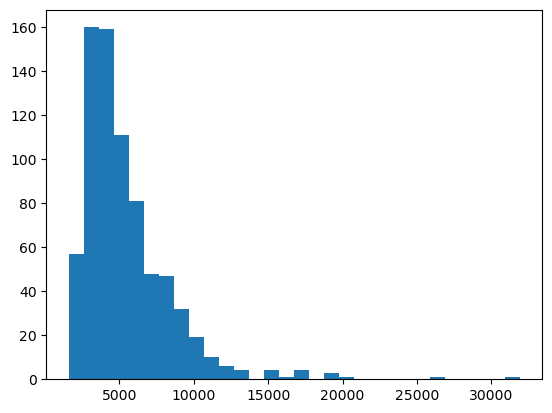

In [101]:
_ = plt.hist(x=df_weights_combined["rt"], bins=30)

In [102]:
df_weights_combined.loc[df_weights_combined["rt"] > 15000, "rt"] = np.nan

In [103]:
f_partial = partial(corr_weight, col_str_fixed = "avg_weight", df_cor = df_weights_combined)
l_cors_weight = list(map(f_partial, cols_corr_combined))
df_corr_weight = pd.DataFrame({"var":cols_corr_combined, "r":[float(c[0]) for c in l_cors_weight], "pval":[float(c[1]) for c in l_cors_weight]})
df_corr_weight_all = df_corr_weight.sort_values("r", ascending=False).reset_index(drop=True)

f_partial = partial(corr_weight, col_str_fixed = "weights_delta_abs_sum", df_cor = df_weights_combined)
l_cors_weight_change = list(map(f_partial, cols_corr_combined))
df_corr_weight_change = pd.DataFrame({"var":cols_corr_combined, "r":[float(c[0]) for c in l_cors_weight_change], "pval":[float(c[1]) for c in l_cors_weight_change]})
df_corr_weight_change_all = df_corr_weight_change.sort_values("r", ascending=False).reset_index(drop=True)

f_partial = partial(corr_weight, col_str_fixed = "gini_overall", df_cor = df_weights_combined)
l_cors_gini = list(map(f_partial, cols_corr_combined))
df_corr_gini = pd.DataFrame({"var":cols_corr_combined, "r":[float(c[0]) for c in l_cors_gini], "pval":[float(c[1]) for c in l_cors_gini]})
df_corr_gini_all = df_corr_gini.sort_values("r", ascending=False).reset_index(drop=True)

In [104]:
df_corr_weight = pd.concat([df_corr_weight_new, df_corr_weight_all]).sort_values("pval")
df_corr_weight_change = pd.concat([df_corr_weight_change_new, df_corr_weight_change_all]).sort_values("pval")
df_corr_gini = pd.concat([df_corr_gini_new, df_corr_gini_all]).sort_values("pval")

In [105]:
df_corr_weight.query("pval <= .08")

,var,r,pval
0,Sex_0,0.150586,0.000035
14,Extraversion,-0.174833,0.014001
0,Negative_Emotionality,0.158035,0.026557
1,motivation_1,0.146747,0.039615
2,rt,-0.074412,0.043580
1,age,0.073219,0.045158
13,income_0,-0.140448,0.049009


In [106]:
df_corr_weight_change.query("pval <= 0.08")

,var,r,pval
0,rt,0.089689,0.014935
0,Negative_Emotionality,0.144996,0.042060
14,income_0,-0.134767,0.059008
2,age,-0.066068,0.070747
1,Detachment,0.127985,0.073085


In [107]:
df_corr_gini.query("pval <= 0.08")

,var,r,pval
0,rt,0.151361,0.000037
2,age,-0.132413,0.000279
1,Sex_0,-0.114532,0.001692
0,income_0,0.143924,0.043620
1,Conscientiousness,0.131717,0.065036
2,Extraversion,0.129847,0.068972


In [108]:
def my_pearsonr(x, y, my_df):
    r = pearsonr(my_df[x], my_df[y])
    dict_r = {"r":r[0], "pvalue":r[1], "Dimension":x, "Variable":y}
    return dict_r

def max_corr_dimweights(l_col, my_df):
    pearsonr_partial = partial(my_pearsonr, y = l_col, my_df=my_df)
    l_cors = list(map(pearsonr_partial, colnames_dim_weights))
    return l_cors

In [109]:
partial_maxcorr = partial(max_corr_dimweights, my_df = df_ooo_qs)
l_max_corrs_new = list(map(partial_maxcorr, ["motivation_1", "edu"]))

partial_maxcorr = partial(max_corr_dimweights, my_df = df_weights_combined)
l_max_corrs_all = list(map(partial_maxcorr, ["age", "Sex_0"]))

In [110]:
df_max_corrs_new = reduce(lambda x, y: pd.concat([x, y], ignore_index=True),
            [pd.DataFrame.from_dict(d) for d in l_max_corrs_new])
df_max_corrs_all = reduce(lambda x, y: pd.concat([x, y], ignore_index=True),
            [pd.DataFrame.from_dict(d) for d in l_max_corrs_all])
df_max_corrs = pd.concat([df_max_corrs_new, df_max_corrs_all])
# Sample renaming dictionary
rename_dict = {
    "motivation_1": "Motivation (Self Report)",
    "edu": "Years Education",
    "age": "Age",
    "Sex_0": "Gender (1: Women)"
}

# Apply renaming
df_max_corrs["Variable"] = df_max_corrs["Variable"].replace(rename_dict)

In [111]:
def rename_and_sort_col_for_plot(my_df):
    my_df.loc[my_df["var"] == "motivation_1", "var"] = "Motivation (Self Report)"
    my_df.loc[my_df["var"] == "age", "var"] = "Age"
    my_df.loc[my_df["var"] == "edu", "var"] = "Years Education"
    my_df.loc[my_df["var"] == "Sex_0", "var"] = "Gender (1: Women)"
    my_df.loc[my_df["var"] == "Negative_Emotionality", "var"] = "Negative Emotionality"
    my_df.loc[my_df["var"] == "income_0", "var"] = "Income"
    my_df.loc[my_df["var"] == "Open_Mindedness", "var"] = "Open Mindedness"
    my_df.loc[my_df["var"] == "rt", "var"] = "Avg. Triplet RT"

    my_df = my_df.sort_values("r", ascending=False)

    return my_df

In [112]:
df_corr_weight = rename_and_sort_col_for_plot(df_corr_weight)
df_corr_weight_change = rename_and_sort_col_for_plot(df_corr_weight_change)
df_corr_gini = rename_and_sort_col_for_plot(df_corr_gini)

In [113]:
df_corr_weight

,var,r,pval
0,Negative Emotionality,0.158035,0.026557
0,Gender (1: Women),0.150586,0.000035
1,Motivation (Self Report),0.146747,0.039615
2,Detachment,0.122411,0.086595
3,Years Education,0.086398,0.227357
4,idx,0.078918,0.270315
1,Age,0.073219,0.045158
5,Psychoticism,0.066977,0.349720
6,Negative Affect,0.043033,0.548219
7,Open Mindedness,0.001705,0.981034


In [114]:
df_corr_weight.to_csv("data/dataframes-plotting-ms/avgweight-cors-d35.csv")
df_corr_weight_change.to_csv("data/dataframes-plotting-ms/weightconsistency-cors-d35.csv")
df_corr_gini.to_csv("data/dataframes-plotting-ms/gini-cors-d35.csv")

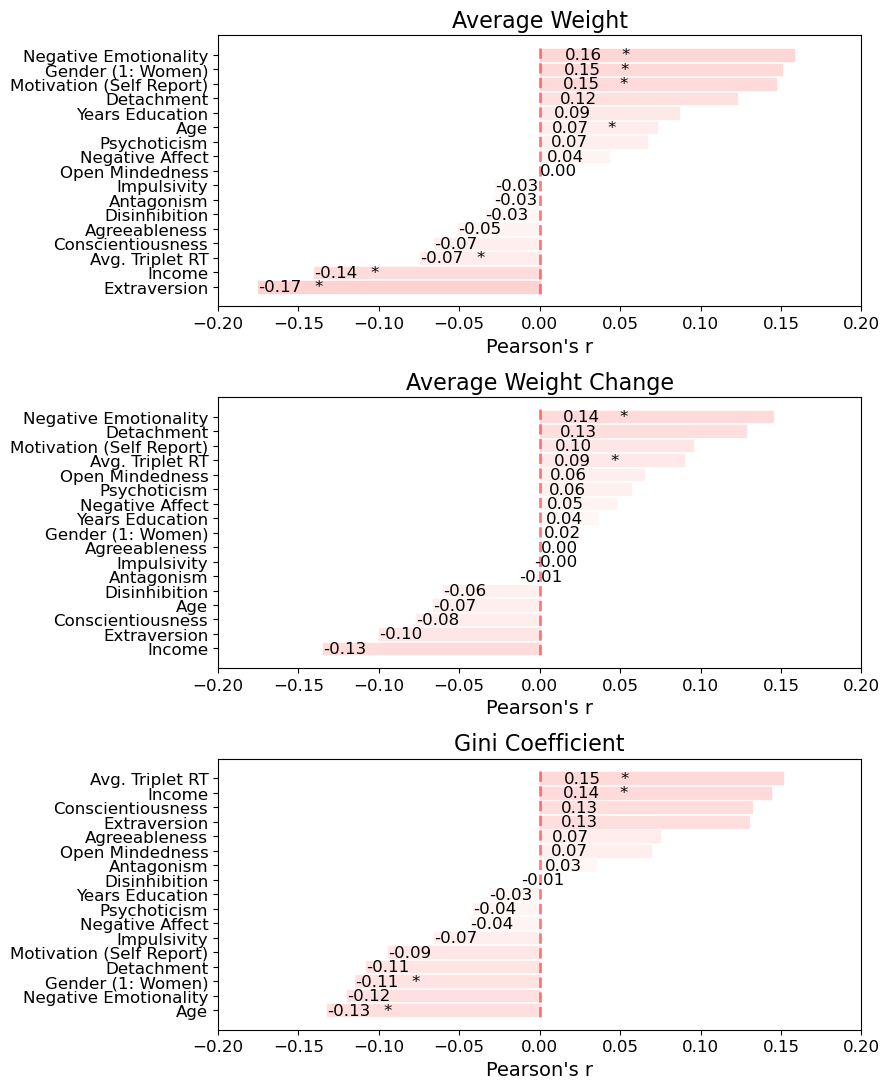

In [115]:
f_all, axes = plt.subplots(nrows=3, figsize=(9, 11))
ut.barplot_cols(df_corr_weight.query("var not in ['idx']").copy(), "Average Weight", f_all, axes[0])
ut.barplot_cols(df_corr_weight_change.query("var not in ['idx']").copy(), "Average Weight Change", f_all, axes[1])
ut.barplot_cols(df_corr_gini.query("var not in ['idx']").copy(), "Gini Coefficient", f_all, axes[2])
plt.tight_layout()

# Plot Objects With Highest Values on the Dimensions

In [68]:
df_embeddings_full = pd.DataFrame(l_results_full[idx_full]["item_embeddings"].detach().numpy().transpose()).reset_index()
df_embeddings_full.columns = ["image_id"] + [i for i in range(0, l_embed_dim[0])]

In [69]:
import re
l_concepts = os.listdir("data/images/")
l_m = [re.match("^[a-z]", l_concepts[i]) for i in range(0, len(l_concepts))]
l_filter = [l_m[i] != None for i in range(0, len(l_concepts))]
l_concepts_filtered = [value for value, flag in zip(l_concepts, l_filter) if flag]
f_partial = partial(ut.extract_image, l_concepts_filtered)

FileNotFoundError: [Errno 2] No such file or directory: 'data/images/'

In [ ]:
# Normalize correlation to [0, 1] for size scaling
n_images_plot = 10

f, axes = plt.subplots(
    n_images_plot, l_embed_dim[0], 
    figsize=(l_embed_dim[0] * 1.5, n_images_plot * 1.5)
)

for current_dim in range(0, l_embed_dim[0]):
    
    lot_coded = df_embeddings_full[["image_id", current_dim]].sort_values(current_dim, ascending=False).reset_index(drop=True)
    
    l_ids_lot_coded = lot_coded.loc[0:(n_images_plot-1), "image_id"]
    paths_lot_coded = list(map(f_partial, l_ids_lot_coded))
    
    for j in range(n_images_plot):
        img = Image.open(paths_lot_coded[j])
        axes[j, current_dim].imshow(img)
        axes[j, current_dim].axis("off")
        
plt.tight_layout()